In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import pickle
import warnings
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    mean_absolute_error
)

warnings.filterwarnings('ignore')

# Load dataset

In [51]:
data = pd.read_csv('Fertilizer_Dataset.csv')

# Drop unnecessary columns

In [52]:
data.drop(columns=['Link', 'District_Name'], inplace=True)

# Check data

In [53]:
data.head()

,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer
0,Black,75,50,100,6.5,1000,20,Sugarcane,Urea
1,Black,80,50,100,6.5,1000,20,Sugarcane,Urea
2,Black,85,50,100,6.5,1000,20,Sugarcane,Urea
3,Black,90,50,100,6.5,1000,20,Sugarcane,Urea
4,Black,95,50,100,6.5,1000,20,Sugarcane,Urea


# Encode Soil_color


In [54]:
encoder = LabelEncoder()
Soil = encoder.fit_transform(data['Soil_color'])

# Map crops


In [55]:
crops = np.unique(data['Crop'].values)
map_crops = np.transpose([crops, [i for i in range(len(crops))]])

# Map fertilizers


In [56]:
fertilizers = np.unique(data['Fertilizer'].values)
map_fertilizers = np.transpose([fertilizers, [i for i in range(len(fertilizers))]])

# Feature matrix (Soil + numeric values)


In [57]:
X = np.column_stack((Soil, data.iloc[:, 1:7].values))


# Target


In [ ]:
y = data.iloc[:, 7:].values

# Convert crop labels to numbers


In [59]:
y_crop = []
for crop in y[:, 0]:
    for i in map_crops:
        if crop == i[0]:
            y_crop.append(i[1])

# Convert fertilizer labels to numbers

In [60]:
y_fert = []
for fert in y[:, 1]:
    for i in map_fertilizers:
        if fert == i[0]:
            y_fert.append(i[1])

y_numeric = np.transpose(np.array([y_crop, y_fert]))

# Train Test Split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_numeric, test_size=0.25, random_state=42
)

# Train model

In [62]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### 10-FOLD CROSS VALIDATION:

In [63]:
print("\n===================================")
print("   10-FOLD CROSS VALIDATION")
print("===================================")

# Crop prediction CV accuracy
cv_crop = cross_val_score(dt, X, y[:,0], cv=10, scoring='accuracy')
print("\nCrop CV Accuracy (10-Fold):")
print("Scores:", cv_crop)
print("Mean Accuracy:", cv_crop.mean())

# Fertilizer prediction CV accuracy
cv_fert = cross_val_score(dt, X, y[:,1], cv=10, scoring='accuracy')
print("\nFertilizer CV Accuracy (10-Fold):")
print("Scores:", cv_fert)
print("Mean Accuracy:", cv_fert.mean())


   10-FOLD CROSS VALIDATION

Crop CV Accuracy (10-Fold):
Scores: [0.75221239 0.90929204 0.93362832 0.92682927 0.93569845 0.97117517
 0.97560976 0.97782705 0.96230599 0.70066519]
Mean Accuracy: 0.9045243608107845

Fertilizer CV Accuracy (10-Fold):
Scores: [0.26548673 0.41814159 0.34292035 0.30155211 0.28381375 0.25498891
 0.47450111 0.33481153 0.3037694  0.30820399]
Mean Accuracy: 0.3288189470792536


# Prediction

In [64]:
y_pred = dt.predict(X_test)

print(classification_report(y_test[:,0], y_pred[:,0]))
print(classification_report(y_test[:,1], y_pred[:,1]))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99       177
           1       1.00      1.00      1.00        28
           2       0.95      1.00      0.97        18
           3       1.00      1.00      1.00        23
           4       0.98      1.00      0.99        50
           5       0.93      0.98      0.95        81
           6       0.99      0.99      0.99        86
           7       1.00      1.00      1.00         5
           8       1.00      0.88      0.94        17
           9       0.99      0.98      0.98        83
          10       1.00      0.89      0.94         9
          11       1.00      1.00      1.00       255
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        15
          14       1.00      0.86      0.93        29
          15       0.98      1.00      0.99       229

    accuracy                           0.99      1129
   macro avg       0.99   

### MODEL EVALUATION:

        MODEL EVALUATION

🔹 Accuracy:
Crop Accuracy: 0.9875996457041629
Fertilizer Accuracy: 0.9317980513728964

🔹 Classification Report (Crop):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       177
           1       1.00      1.00      1.00        28
           2       0.95      1.00      0.97        18
           3       1.00      1.00      1.00        23
           4       0.98      1.00      0.99        50
           5       0.93      0.98      0.95        81
           6       0.99      0.99      0.99        86
           7       1.00      1.00      1.00         5
           8       1.00      0.88      0.94        17
           9       0.99      0.98      0.98        83
          10       1.00      0.89      0.94         9
          11       1.00      1.00      1.00       255
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        15
          14       1.00      0.86      0.93 

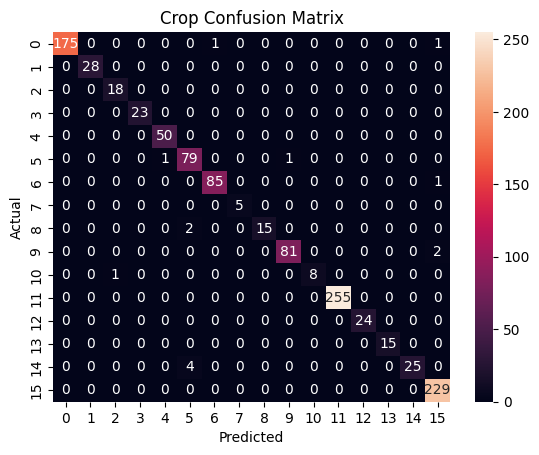

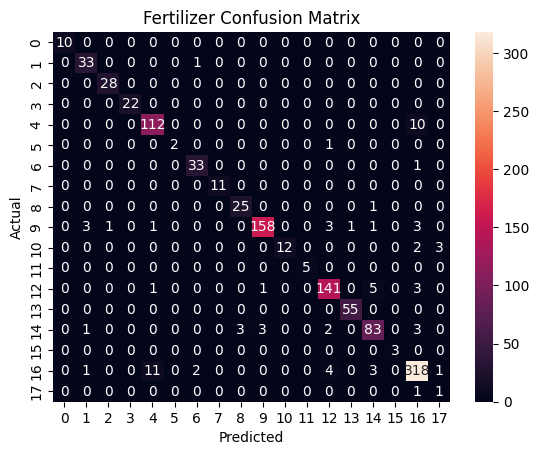


🔹 Hamming Loss:
Hamming Loss: 0.04030115146147033

🔹 Exact Match Ratio: 0.9317980513728964

🔹 Mean Absolute Error:
0.28343666961913194

🔹 Feature Importance:


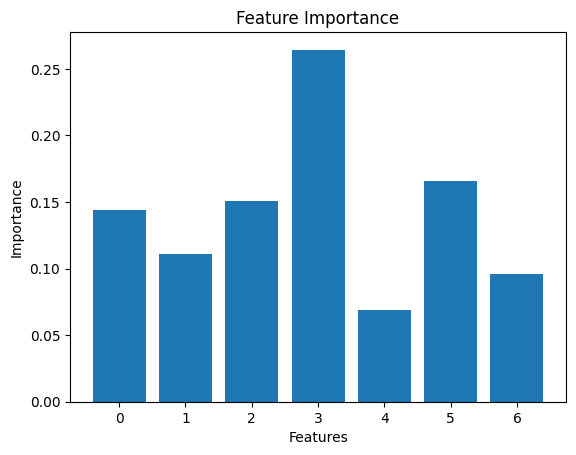

In [65]:

print("===================================")
print("        MODEL EVALUATION")
print("===================================")

# 🔹 Accuracy
print("\n🔹 Accuracy:")
print("Crop Accuracy:", accuracy_score(y_test[:,0], y_pred[:,0]))
print("Fertilizer Accuracy:", accuracy_score(y_test[:,1], y_pred[:,1]))


# 🔹 Classification Report
print("\n🔹 Classification Report (Crop):")
print(classification_report(y_test[:,0], y_pred[:,0]))

print("\n🔹 Classification Report (Fertilizer):")
print(classification_report(y_test[:,1], y_pred[:,1]))


# 🔹 Precision, Recall, F1
print("\n🔹 Precision / Recall / F1 (Crop):")
print("Precision:", precision_score(y_test[:,0], y_pred[:,0], average='weighted'))
print("Recall:", recall_score(y_test[:,0], y_pred[:,0], average='weighted'))
print("F1 Score:", f1_score(y_test[:,0], y_pred[:,0], average='weighted'))


# 🔹 Confusion Matrix
print("\n🔹 Confusion Matrix:")

# Crop
cm_crop = confusion_matrix(y_test[:,0], y_pred[:,0])
plt.figure()
sns.heatmap(cm_crop, annot=True, fmt='d')
plt.title("Crop Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Fertilizer
cm_fert = confusion_matrix(y_test[:,1], y_pred[:,1])
plt.figure()
sns.heatmap(cm_fert, annot=True, fmt='d')
plt.title("Fertilizer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


print("\n🔹 Hamming Loss:")

# Manual Hamming Loss for multiclass-multioutput
hamming = np.not_equal(y_test, y_pred).sum() / (y_test.shape[0] * y_test.shape[1])

print("Hamming Loss:", hamming)

# 🔹 Exact Match Ratio
exact_match = np.all(y_test == y_pred, axis=1)
print("\n🔹 Exact Match Ratio:", np.mean(exact_match))


# 🔹 Mean Absolute Error
print("\n🔹 Mean Absolute Error:")
print(mean_absolute_error(y_test, y_pred))


# 🔹 Feature Importance
print("\n🔹 Feature Importance:")
importance = dt.feature_importances_

plt.figure()
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Example input

In [66]:
input_data = ['Black', 25, 35, 35, 7.5, 800, 25]

input_data[0] = int(encoder.transform([input_data[0]]))
input_data = np.array(input_data).reshape(1,-1)

prediction = dt.predict(input_data)[0]


# Decode prediction

In [67]:
for i in map_crops:
    if i[1] == prediction[0]:
        predicted_crop = i[0]
        break

for i in map_fertilizers:
    if i[1] == prediction[1]:
        predicted_fertilizer = i[0]
        break

print(f"Predicted Crop: {predicted_crop}")
print(f"Predicted Fertilizer: {predicted_fertilizer}")

Predicted Crop: Jowar
Predicted Fertilizer: 10:26:26 NPK


# -----------------------------
# Save Model as PKL
# -----------------------------

In [68]:

model_data = {
    "model": dt,
    "soil_encoder": encoder,
    "crop_map": map_crops,
    "fertilizer_map": map_fertilizers
}

with open("crop_fertilizer_model.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("Model saved successfully as crop_fertilizer_model.pkl")

Model saved successfully as crop_fertilizer_model.pkl
